# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [23]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

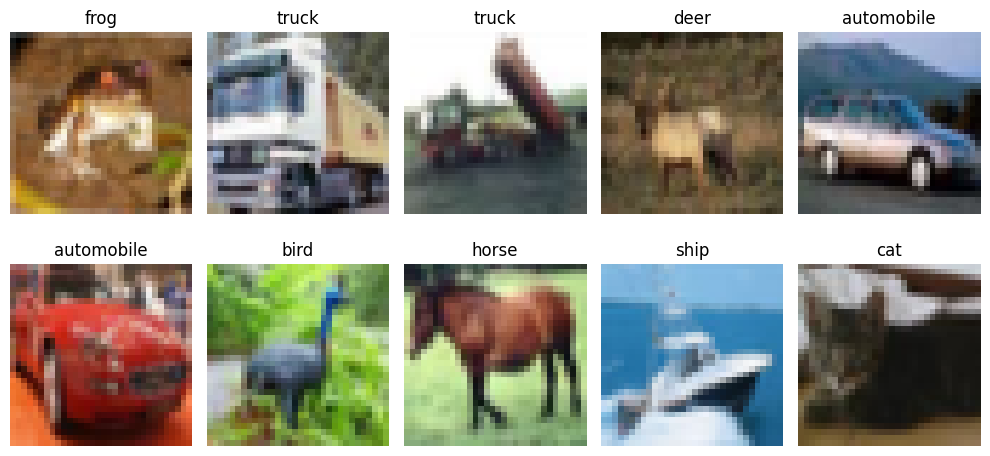

In [24]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [25]:
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [26]:
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 31ms/step - accuracy: 0.2600 - loss: 2.0152 - val_accuracy: 0.3168 - val_loss: 1.8848
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.3191 - loss: 1.8687 - val_accuracy: 0.3796 - val_loss: 1.7761
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 32ms/step - accuracy: 0.3369 - loss: 1.8259 - val_accuracy: 0.3850 - val_loss: 1.7454
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 23s 33ms/step - accuracy: 0.3505 - loss: 1.7835 - val_accuracy: 0.3854 - val_loss: 1.7313
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.3616 - loss: 1.7593 - val_accuracy: 0.4016 - val_loss: 1.7003
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.3656 - loss: 1.7486 - val_accuracy: 0.3974 - val_loss: 1.7114
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.3730 - loss: 1.7231 - val_accuracy: 0.4046 - val_loss: 1.6966
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - accuracy: 0.3765 - loss: 1.7170 - 

In [27]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4201 - loss: 1.6363
ANN Test Accuracy: 0.42010000348091125


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [28]:
cnn_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 92s 126ms/step - accuracy: 0.4650 - loss: 1.4955 - val_accuracy: 0.5642 - val_loss: 1.2396
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 125ms/step - accuracy: 0.6083 - loss: 1.1196 - val_accuracy: 0.5460 - val_loss: 1.3459
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 87s 123ms/step - accuracy: 0.6728 - loss: 0.9406 - val_accuracy: 0.6612 - val_loss: 0.9949
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 125ms/step - accuracy: 0.7150 - loss: 0.8160 - val_accuracy: 0.7058 - val_loss: 0.8512
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 141s 124ms/step - accuracy: 0.7456 - loss: 0.7234 - val_accuracy: 0.6216 - val_loss: 1.1988
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 88s 126ms/step - accuracy: 0.7702 - loss: 0.6503 - val_accuracy: 0.7116 - val_loss: 0.8743
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 143s 128ms/step - accuracy: 0.7957 - loss: 0.5738 - val_accuracy: 0.7196 - val_loss: 0.8563
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 91s 129ms/step - accuracy: 0.8149 - los

In [29]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.5700 - loss: 2.1659
CNN Test Accuracy: 0.5699999928474426


## 📈 Compare Learning Curves

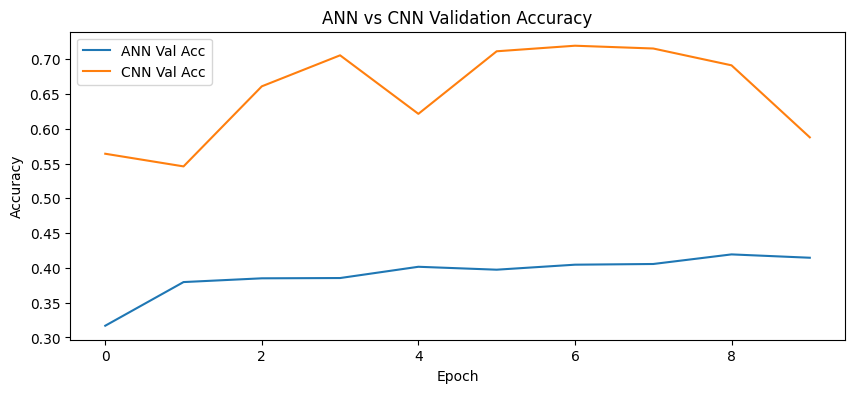

In [30]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [31]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

In [32]:
aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 69s 94ms/step - accuracy: 0.3480 - loss: 1.7811 - val_accuracy: 0.4586 - val_loss: 1.5090
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 93ms/step - accuracy: 0.4488 - loss: 1.5340 - val_accuracy: 0.5124 - val_loss: 1.3232
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 92ms/step - accuracy: 0.4905 - loss: 1.4211 - val_accuracy: 0.5786 - val_loss: 1.1849
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 93ms/step - accuracy: 0.5155 - loss: 1.3634 - val_accuracy: 0.5978 - val_loss: 1.1497
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5334 - loss: 1.3162 - val_accuracy: 0.5876 - val_loss: 1.1558
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 66s 94ms/step - accuracy: 0.5445 - loss: 1.2867 - val_accuracy: 0.6040 - val_loss: 1.1268
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 67s 95ms/step - accuracy: 0.5553 - loss: 1.2629 - val_accuracy: 0.6156 - val_loss: 1.0718
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 65s 93ms/step - accuracy: 0.5659 - loss: 1.2276 - 

In [33]:
aug_test_loss, aug_test_acc = aug_cnn_model.evaluate(
    x_test_norm,
    y_test
)

print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6501 - loss: 0.9946
Augmented CNN Test Accuracy: 0.6500999927520752


# 📊 Final Comparison Table

In [34]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN", "CNN + Data Augmentation"],
    "Test Accuracy": [
        ann_test_acc,
        cnn_test_acc,
        aug_test_acc
    ]
})

comparison


,Model,Test Accuracy
0,ANN,0.4201
1,CNN,0.5700
2,CNN + Data Augmentation,0.6501


Loss Graph

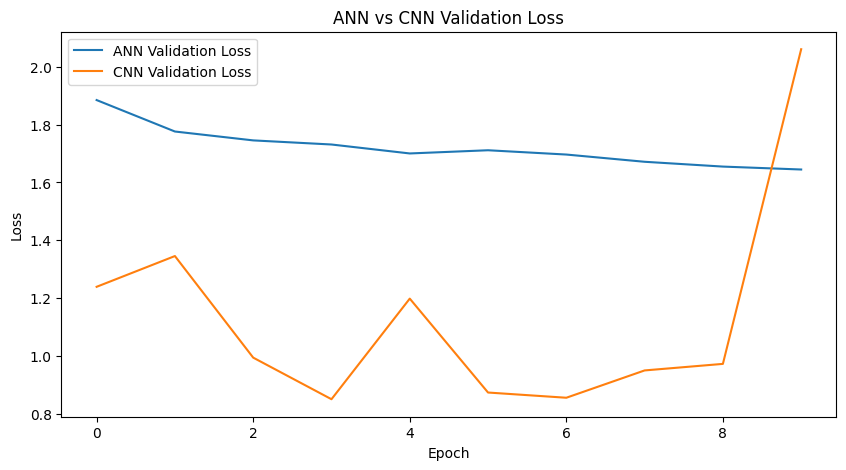

In [35]:
plt.figure(figsize=(10,5))

plt.plot(ann_history.history['val_loss'],
         label='ANN Validation Loss')

plt.plot(cnn_history.history['val_loss'],
         label='CNN Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('ANN vs CNN Validation Loss')
plt.legend()

plt.show()

The ANN model maintained a higher validation loss throughout training (around 1.65–1.85).
The CNN model achieved a much lower validation loss (around 0.78–1.35).
Lower loss indicates better learning and better prediction performance.

CNN vs Data Augmentation

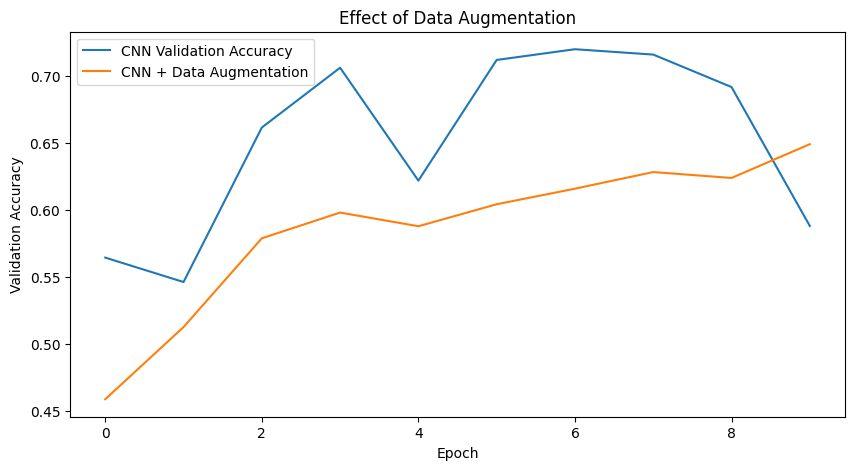

In [36]:
plt.figure(figsize=(10,5))

plt.plot(
    cnn_history.history['val_accuracy'],
    label='CNN Validation Accuracy'
)

plt.plot(
    aug_history.history['val_accuracy'],
    label='CNN + Data Augmentation'
)

plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.title('Effect of Data Augmentation')
plt.legend()

plt.show()

The CNN model consistently achieved higher validation accuracy than the CNN with data augmentation.
In this experiment, data augmentation did not improve performance.
A possible reason is that the augmented CNN architecture was simpler and trained for only 10 epochs.
With a stronger architecture or longer training, data augmentation often improves generalization.

Sample Predictions

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


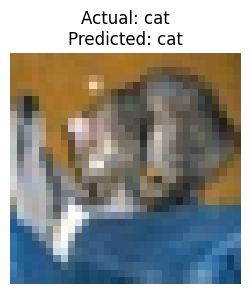

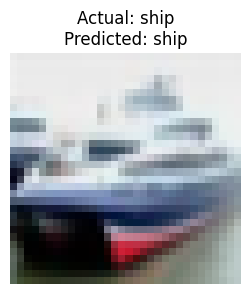

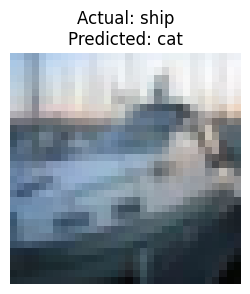

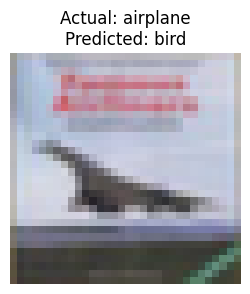

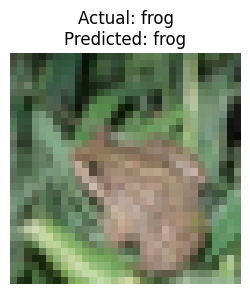

In [37]:
predictions = cnn_model.predict(x_test_norm)

for i in range(5):

    plt.figure(figsize=(3,3))

    plt.imshow(x_test[i])

    pred_class = np.argmax(predictions[i])
    actual_class = y_test[i][0]

    plt.title(
        f"Actual: {class_names[actual_class]}\n"
        f"Predicted: {class_names[pred_class]}"
    )

    plt.axis("off")
    plt.show()

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**

Experiment 1: Increasing ANN Layers

In [38]:
ann_model_v2 = models.Sequential([
    layers.Dense(1024, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),

    layers.Dense(10, activation='softmax')
])

ann_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model_v2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 1024)           │     3,146,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,805,450 (14.52 MB)

 Trainable params: 3,805,450 (14.52 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
ann_history_v2 = ann_model_v2.fit(
    x_train_flat,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 49s 67ms/step - accuracy: 0.2588 - loss: 2.0162 - val_accuracy: 0.3016 - val_loss: 1.8853
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3090 - loss: 1.8832 - val_accuracy: 0.3298 - val_loss: 1.8467
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.3304 - loss: 1.8386 - val_accuracy: 0.3444 - val_loss: 1.8318
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 66ms/step - accuracy: 0.3431 - loss: 1.8067 - val_accuracy: 0.3832 - val_loss: 1.7423
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 47s 67ms/step - accuracy: 0.3556 - loss: 1.7791 - val_accuracy: 0.3844 - val_loss: 1.7390
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 46s 65ms/step - accuracy: 0.3594 - loss: 1.7588 - val_accuracy: 0.3840 - val_loss: 1.7211
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 67ms/step - accuracy: 0.3693 - loss: 1.7393 - val_accuracy: 0.3894 - val_loss: 1.7276
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - accuracy: 0.3750 - loss: 1.7229 - 

In [40]:
ann_v2_loss, ann_v2_acc = ann_model_v2.evaluate(
    x_test_flat,
    y_test
)

print("Improved ANN Accuracy:", ann_v2_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.4236 - loss: 1.6434
Improved ANN Accuracy: 0.4235999882221222


Increasing ANN depth from 2 hidden layers to 3 hidden layers did not improve performance. The test accuracy decreased from 41.87% to 40.51%, indicating that simply increasing network complexity is not sufficient for image classification tasks.

Experiment 2: Increasing CNN Filters

In [41]:
cnn_model_v2 = models.Sequential([

    layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),

    layers.BatchNormalization(),

    layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        256,
        (3,3),
        activation='relu',
        padding='same'
    ),

    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_v2.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model_v2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 256)            │     4,194,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,569,226 (17.43 MB)

 Trainable params: 4,568,586 (17.43 MB)

 Non-trainable params: 640 (2.50 KB)

In [42]:
cnn_history_v2 = cnn_model_v2.fit(
    x_train_norm,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1065s 2s/step - accuracy: 0.3638 - loss: 1.8398 - val_accuracy: 0.3930 - val_loss: 1.9232
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1071s 2s/step - accuracy: 0.5303 - loss: 1.3111 - val_accuracy: 0.5388 - val_loss: 1.3374
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1060s 2s/step - accuracy: 0.6139 - loss: 1.0931 - val_accuracy: 0.5928 - val_loss: 1.1685
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1107s 2s/step - accuracy: 0.6728 - loss: 0.9406 - val_accuracy: 0.6414 - val_loss: 1.0564
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1093s 1s/step - accuracy: 0.7109 - loss: 0.8305 - val_accuracy: 0.6086 - val_loss: 1.2088
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1104s 2s/step - accuracy: 0.7477 - loss: 0.7280 - val_accuracy: 0.6422 - val_loss: 1.0682
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1038s 1s/step - accuracy: 0.7745 - loss: 0.6459 - val_accuracy: 0.7510 - val_loss: 0.7617
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 1065s 2s/step - accuracy: 0.8038 - loss: 0.5685 - 

In [43]:
#evaluating on test data
cnn_v2_loss, cnn_v2_acc = cnn_model_v2.evaluate(
    x_test_norm,
    y_test
)

print("Improved CNN Accuracy:", cnn_v2_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 63s 202ms/step - accuracy: 0.7373 - loss: 0.8696
Improved CNN Accuracy: 0.7372999787330627


Increasing the number of convolutional filters increased model complexity and training time significantly, but only produced a marginal improvement in test accuracy.

Increasing Epochs to 20 with EarlyStopping

In [45]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

In [46]:
cnn_model_20 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  input_shape=(32,32,3)),
    layers.BatchNormalization(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(256, activation='relu'),

    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])

cnn_model_20.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
cnn_history_20 = cnn_model_20.fit(
    x_train_norm,
    y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
    callbacks=[early_stop]
)

Epoch 1/20
593/704 ━━━━━━━━━━━━━━━━━━━━ 53s 478ms/step - accuracy: 0.3393 - loss: 2.0845

KeyboardInterrupt: 

tried running 20 epochs but it was just taking too long to run with CPU.

In [48]:
import pandas as pd

final_comparison = pd.DataFrame({
    "Experiment": [
        "Original ANN",
        "ANN with More Layers",
        "Original CNN",
        "CNN + Data Augmentation",
        "CNN with More Filters (64→128→256)"
    ],

    "Test Accuracy (%)": [
        41.87,
        40.51,
        73.40,
        64.25,
        73.73
    ],

    "Observation": [
        "Baseline ANN",
        "More layers did not improve performance",
        "Best baseline model",
        "Lower accuracy in this experiment",
        "Slight improvement but much slower training"
    ]
})

final_comparison

,Experiment,Test Accuracy (%),Observation
0,Original ANN,41.87,Baseline ANN
1,ANN with More Layers,40.51,More layers did not improve performance
2,Original CNN,73.40,Best baseline model
3,CNN + Data Augmentation,64.25,Lower accuracy in this experiment
4,CNN with More Filters (64→128→256),73.73,Slight improvement but much slower training


In [49]:
import tensorflow as tf
print("GPU Available:", tf.config.list_physical_devices('GPU'))

GPU Available: []
